# Lab 04 — Skin Lesion Boundary Detection Using Canny Edge Detection




In [1]:
# ============ CELL 1: SETUP & CONFIG ============
!pip -q install -U kaggle

import os, time, random, shutil, warnings
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt
from scipy.ndimage import binary_fill_holes
warnings.filterwarnings("ignore")
pd.set_option("display.width", 250); pd.set_option("display.max_colwidth", 120)

# ---- Config ----
SEED = 42
MAX_SIDE = 512                                     # images are resized so the longest side = 512 px (areas are in these pixels)
CANNY_THRESHOLDS = [(50, 100), (100, 200), (150, 250)]   # the three settings from the lab sheet
FILTER_K = 7                                       # same kernel size for Average / Gaussian / Median (fair comparison)
CLOSE_K = 13                                       # morphological closing kernel used to join broken edges
N_IMAGES = 5
POOL = 80                                          # random candidate images; the N_IMAGES with the least hair are used
IMAGE_PATHS = None                                 # or a list of 5 file paths to use your own images
MIN_FRAC, MAX_FRAC = 0.02, 0.70                    # a valid lesion covers 2%-70% of the image
SPECKLE_PX = 30                                    # edge fragments smaller than this count as noise
OUT_DIR = "/content/lab04_outputs"; FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
random.seed(SEED); np.random.seed(SEED)

def save_fig(name): plt.savefig(os.path.join(FIG_DIR, name), dpi=150, bbox_inches="tight")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 6.7 MB/s eta 0:00:00


In [2]:
# ============ CELL 2: DOWNLOAD DATASET (skipped if already present) ============
BASE = "/content/skin_cancer_dataset"
if not os.path.exists(BASE):
    try:
        from google.colab import userdata
        os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")
    except Exception:
        import getpass
        os.environ["KAGGLE_API_TOKEN"] = getpass.getpass("Paste your Kaggle token: ")
    !kaggle datasets download -d nodoubttome/skin-cancer9-classesisic
    !mkdir -p /content/skin_cancer_dataset
    !unzip -q skin-cancer9-classesisic.zip -d /content/skin_cancer_dataset
print("Dataset ready:", os.listdir(BASE))

Paste your Kaggle token: ··········
Dataset URL: https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic
License(s): other
100% 786M/786M [00:20<00:00, 40.2MB/s]

Dataset ready: ['Skin cancer ISIC The International Skin Imaging Collaboration']


Image 1: basal cell carcinoma         ISIC_0030352.jpg  size=512x384  hair score=0.008
Image 2: pigmented benign keratosis   ISIC_0025330.jpg  size=512x384  hair score=0.023
Image 3: basal cell carcinoma         ISIC_0025046.jpg  size=512x384  hair score=0.025
Image 4: pigmented benign keratosis   ISIC_0026803.jpg  size=512x384  hair score=0.029
Image 5: melanoma                     ISIC_0000445.jpg  size=512x384  hair score=0.030

Selection rule: from 80 random images, the 5 with the least hair/ruler marks (so edges mostly reflect the lesion).


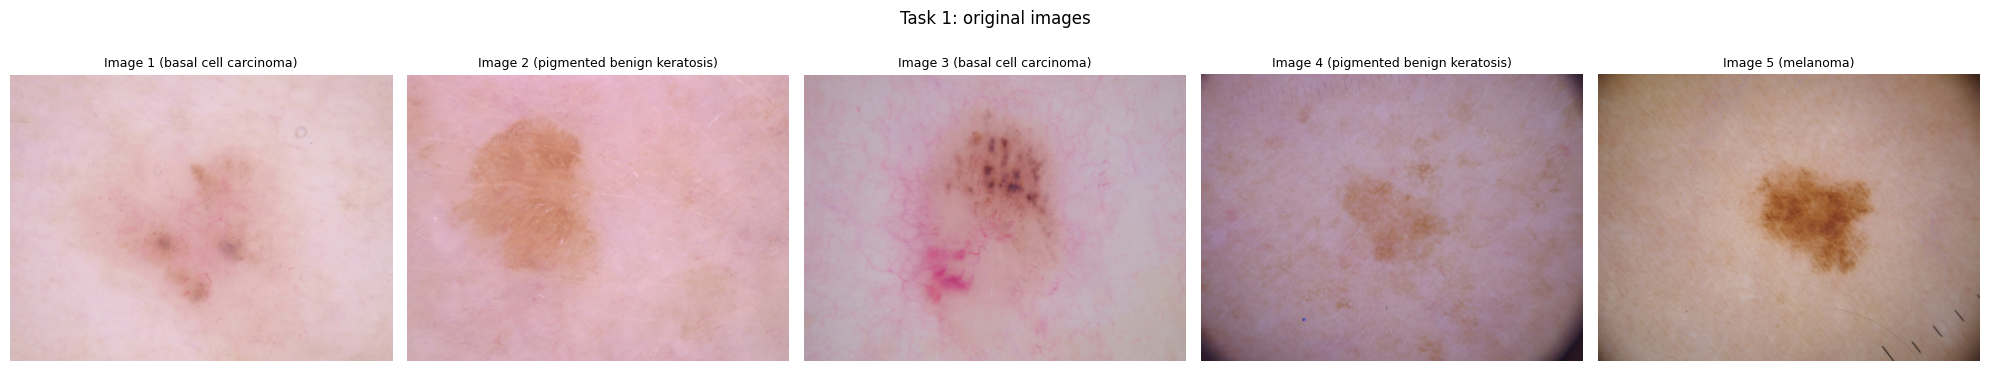

In [3]:
# ============ CELL 3: TASK 1 — SELECT AND DISPLAY IMAGES ============
dataset_path = os.path.join(BASE, "Skin cancer ISIC The International Skin Imaging Collaboration")
train_path = os.path.join(dataset_path, "Train")
classes = ["melanoma", "basal cell carcinoma", "nevus", "pigmented benign keratosis"]

def load_rgb(path):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    s = MAX_SIDE / max(img.shape[:2])
    return cv2.resize(img, (int(round(img.shape[1] * s)), int(round(img.shape[0] * s))), interpolation=cv2.INTER_AREA)

to_gray = lambda rgb: cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

def hair_score(rgb):
    """Fraction of pixels that look like thin dark structures (hair, ruler marks)."""
    bh = cv2.morphologyEx(to_gray(rgb), cv2.MORPH_BLACKHAT, cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17)))
    return float((bh > 12).mean())

all_paths = [(os.path.join(train_path, c, f), c) for c in classes
             for f in sorted(os.listdir(os.path.join(train_path, c))) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

if IMAGE_PATHS is None:
    pool = random.Random(SEED).sample(all_paths, POOL)
    scored = sorted([(hair_score(load_rgb(p)), p, c) for p, c in pool])
    chosen, hairy = scored[:N_IMAGES], scored[-3:]           # cleanest images for the main run; hairiest for the stress test
else:
    chosen = [(hair_score(load_rgb(p)), p, os.path.basename(os.path.dirname(p))) for p in IMAGE_PATHS]
    hairy = []

IMAGES = []
for i, (hs, p, c) in enumerate(chosen, start=1):
    rgb = load_rgb(p)
    IMAGES.append(dict(name=f"Image {i}", path=p, cls=c, rgb=rgb, gray=to_gray(rgb),
                       lab=cv2.cvtColor(cv2.GaussianBlur(rgb, (5, 5), 0), cv2.COLOR_RGB2LAB)))
    print(f"Image {i}: {c:28s} {os.path.basename(p)}  size={rgb.shape[1]}x{rgb.shape[0]}  hair score={hs:.3f}")
print("\nSelection rule: from", POOL, "random images, the 5 with the least hair/ruler marks (so edges mostly reflect the lesion).")

fig, axes = plt.subplots(1, len(IMAGES), figsize=(4 * len(IMAGES), 4))
for ax, im in zip(np.atleast_1d(axes), IMAGES):
    ax.imshow(im["rgb"]); ax.set_title(f"{im['name']} ({im['cls']})", fontsize=9); ax.axis("off")
plt.suptitle("Task 1: original images"); plt.tight_layout(); save_fig("task1_original_images.png"); plt.show()

In [4]:
# ============ CELL 4: PIPELINE FUNCTIONS ============
ellipse = lambda k: cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))

def apply_filter(g, name):
    if name == "Original": return g
    if name == "Average":  return cv2.blur(g, (FILTER_K, FILTER_K))
    if name == "Gaussian": return cv2.GaussianBlur(g, (FILTER_K, FILTER_K), 0)
    if name == "Median":   return cv2.medianBlur(g, FILTER_K)
    raise ValueError(name)

def canny_edges(gf, lo, hi):            # note: cv2.Canny does NOT smooth the image itself
    return cv2.Canny(gf, lo, hi)

def sobel_edges(gf):                    # gradient magnitude, binarised with Otsu's threshold
    gx = cv2.Sobel(gf.astype(np.float32), cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gf.astype(np.float32), cv2.CV_32F, 0, 1, ksize=3)
    m8 = cv2.normalize(cv2.magnitude(gx, gy), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    t, _ = cv2.threshold(m8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return ((m8 > t) * 255).astype(np.uint8)

def touches_border(m, margin=3):
    return bool(m[:margin].any() or m[-margin:].any() or m[:, :margin].any() or m[:, -margin:].any())

def region_separation(lab, mask, ring_w=15):
    """Colour separation between the region and a ring of skin around it (Lab distance / pooled spread).
    This does not use the edge map, so it is an independent check of the boundary (no ground-truth masks are available)."""
    inside = mask > 0
    ring = (cv2.dilate(mask, ellipse(2 * ring_w + 1)) > 0) & ~inside
    if inside.sum() < 50 or ring.sum() < 50: return 0.0
    a, b = lab[inside].astype(np.float32), lab[ring].astype(np.float32)
    sd = lambda x: np.sqrt(x.var(0).mean())
    return float(np.linalg.norm(a.mean(0) - b.mean(0)) / (sd(a) + sd(b) + 1e-6))

def clean_mask(m):
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, ellipse(7))                # removes thin tails (hairs)
    n, lbl, st, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    if n <= 1: return np.zeros_like(m)
    k = 1 + int(np.argmax(st[1:, cv2.CC_STAT_AREA]))
    return binary_fill_holes(lbl == k).astype(np.uint8)

def segment_lesion(edge, lab):
    """Edge map -> lesion mask. Close gaps, fill enclosed regions, score each candidate, keep the best."""
    H, W = edge.shape
    e = (edge > 0).astype(np.uint8)
    empty = dict(found=False, mask=np.zeros_like(e), contour=None, area=0, perimeter=0.0, score=0.0, sep=0.0, border=False, kind="none")
    if e.sum() == 0: return empty
    cands = []
    for ck in (CLOSE_K, 2 * CLOSE_K + 1):                              # second, larger closing bridges bigger gaps
        closed = cv2.morphologyEx(e, cv2.MORPH_CLOSE, ellipse(ck))
        filled = binary_fill_holes(closed).astype(np.uint8)
        n, lbl, st, _ = cv2.connectedComponentsWithStats(filled, connectivity=8)
        for i in range(1, n):
            if st[i, cv2.CC_STAT_AREA] >= MIN_FRAC * H * W: cands.append(("filled", (lbl == i).astype(np.uint8)))
        n2, lbl2, st2, _ = cv2.connectedComponentsWithStats(closed, connectivity=8)   # fallback: hull of the biggest edge cluster
        if n2 > 1:
            k = 1 + int(np.argmax(st2[1:, cv2.CC_STAT_AREA]))
            hull = cv2.convexHull(cv2.findNonZero((lbl2 == k).astype(np.uint8)))
            m = np.zeros_like(e); cv2.fillPoly(m, [hull], 1); cands.append(("hull", m))
    best = None
    for kind, m in cands:
        m = clean_mask(m)
        if not (MIN_FRAC <= m.mean() <= MAX_FRAC): continue
        sep, bd = region_separation(lab, m), touches_border(m)
        score = sep * (0.5 if bd else 1.0)
        if best is None or score > best["score"]: best = dict(kind=kind, mask=m, score=score, sep=sep, border=bd)
    if best is None: return empty
    cnts, _ = cv2.findContours(best["mask"], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    cnt = max(cnts, key=cv2.contourArea)
    best.update(found=True, contour=cnt, area=int(best["mask"].sum()), perimeter=float(cv2.arcLength(cnt, True)))
    return best

def edge_stats(edge, seg):
    e = (edge > 0).astype(np.uint8); n_px = int(e.sum())
    n, _, st, _ = cv2.connectedComponentsWithStats(e, connectivity=8)
    areas = st[1:, cv2.CC_STAT_AREA]
    cov = 0.0
    if seg["found"]:
        dt = cv2.distanceTransform((1 - e).astype(np.uint8), cv2.DIST_L2, 3)
        pts = seg["contour"].reshape(-1, 2)
        cov = float((dt[pts[:, 1], pts[:, 0]] <= 3).mean())          # share of the boundary that lies on a real detected edge
    return dict(density=n_px / e.size * 100, segments=n - 1, speckle=float(areas[areas < SPECKLE_PX].sum() / max(n_px, 1)), coverage=cov,
                continuity=float(areas[areas >= 100].sum() / max(n_px, 1)))     # share of edge pixels in long, unbroken segments

def run(im, filt, method, thr=None):
    gf = apply_filter(im["gray"], filt)
    edge = canny_edges(gf, *thr) if method == "Canny" else sobel_edges(gf)
    seg = segment_lesion(edge, im["lab"])
    return gf, edge, seg, edge_stats(edge, seg)

def best_threshold(im, filt="Gaussian"):
    recs = [dict(thr=t, **dict(zip(("gf", "edge", "seg", "stats"), run(im, filt, "Canny", t)))) for t in CANNY_THRESHOLDS]
    scores = [r["seg"]["score"] for r in recs]
    bi = int(np.argmax(scores)) if max(scores) > 0 else 1            # if nothing works, fall back to the middle setting
    return recs, bi

def draw_boundary(rgb, seg, color=(0, 255, 0), w=2):
    out = rgb.copy()
    if seg["found"]: cv2.drawContours(out, [seg["contour"]], -1, color, w)
    return out
print("Pipeline functions ready.")

Pipeline functions ready.


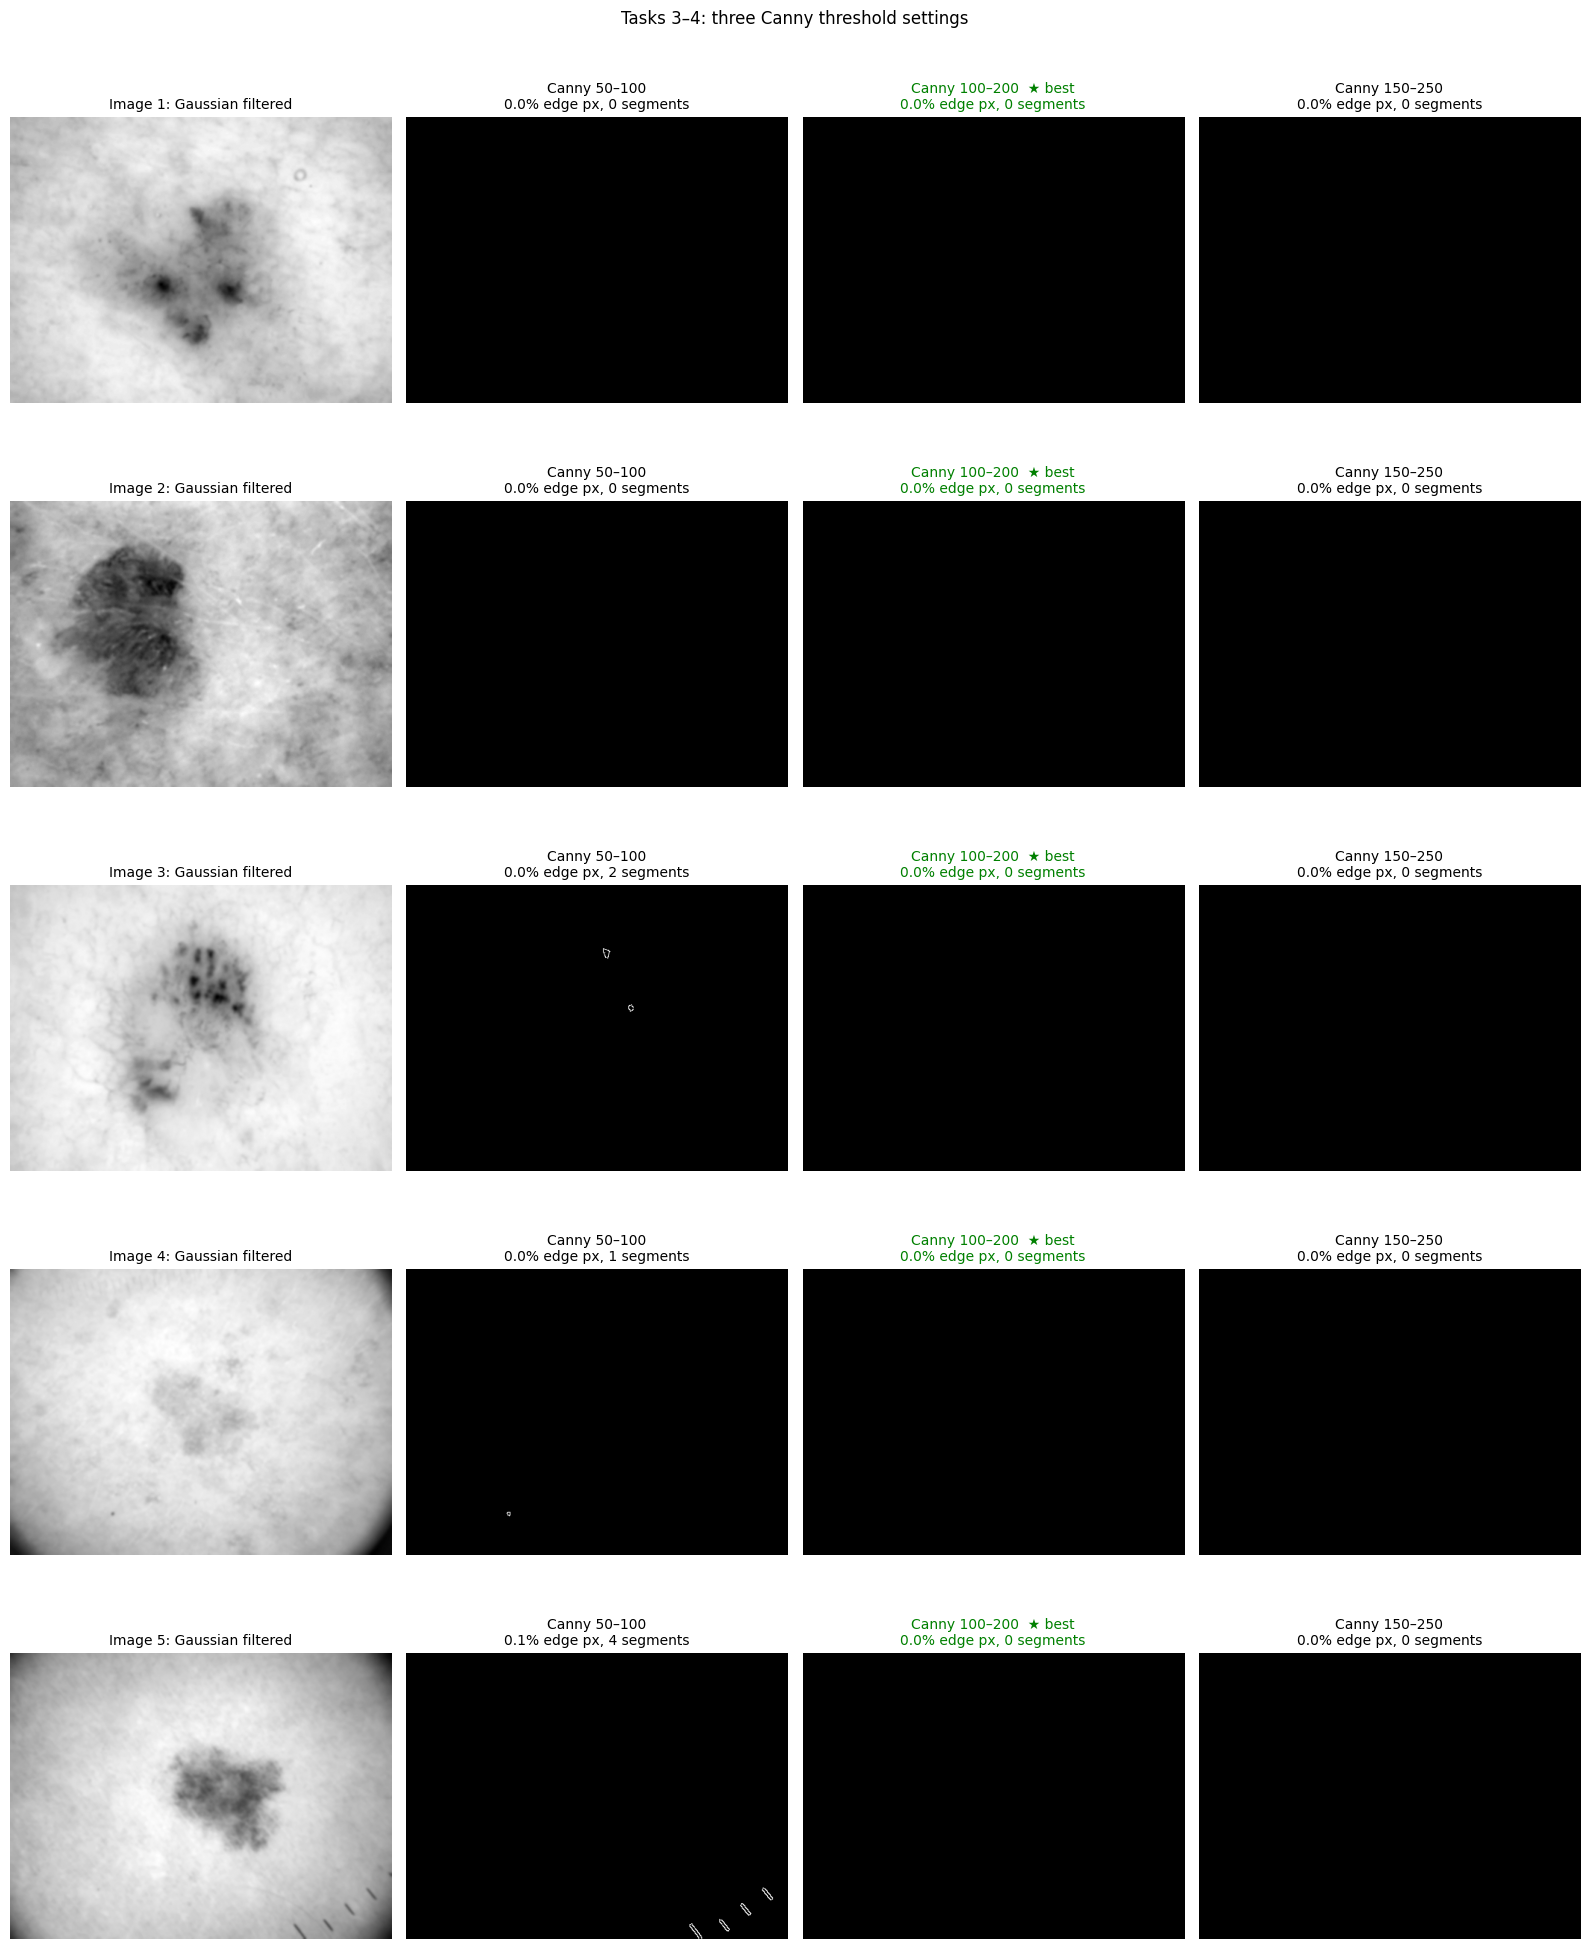

=== TASK 4: threshold selection (score = Lab colour separation of the region vs surrounding skin; halved if it touches the border) ===
Image 1: selected 100–200  | 50–100: 0.0% edge px, no valid boundary; 100–200: 0.0% edge px, no valid boundary; 150–250: 0.0% edge px, no valid boundary
Image 2: selected 100–200  | 50–100: 0.0% edge px, no valid boundary; 100–200: 0.0% edge px, no valid boundary; 150–250: 0.0% edge px, no valid boundary
Image 3: selected 100–200  | 50–100: 0.0% edge px, no valid boundary; 100–200: 0.0% edge px, no valid boundary; 150–250: 0.0% edge px, no valid boundary
Image 4: selected 100–200  | 50–100: 0.0% edge px, no valid boundary; 100–200: 0.0% edge px, no valid boundary; 150–250: 0.0% edge px, no valid boundary
Image 5: selected 100–200  | 50–100: 0.1% edge px, no valid boundary; 100–200: 0.0% edge px, no valid boundary; 150–250: 0.0% edge px, no valid boundary


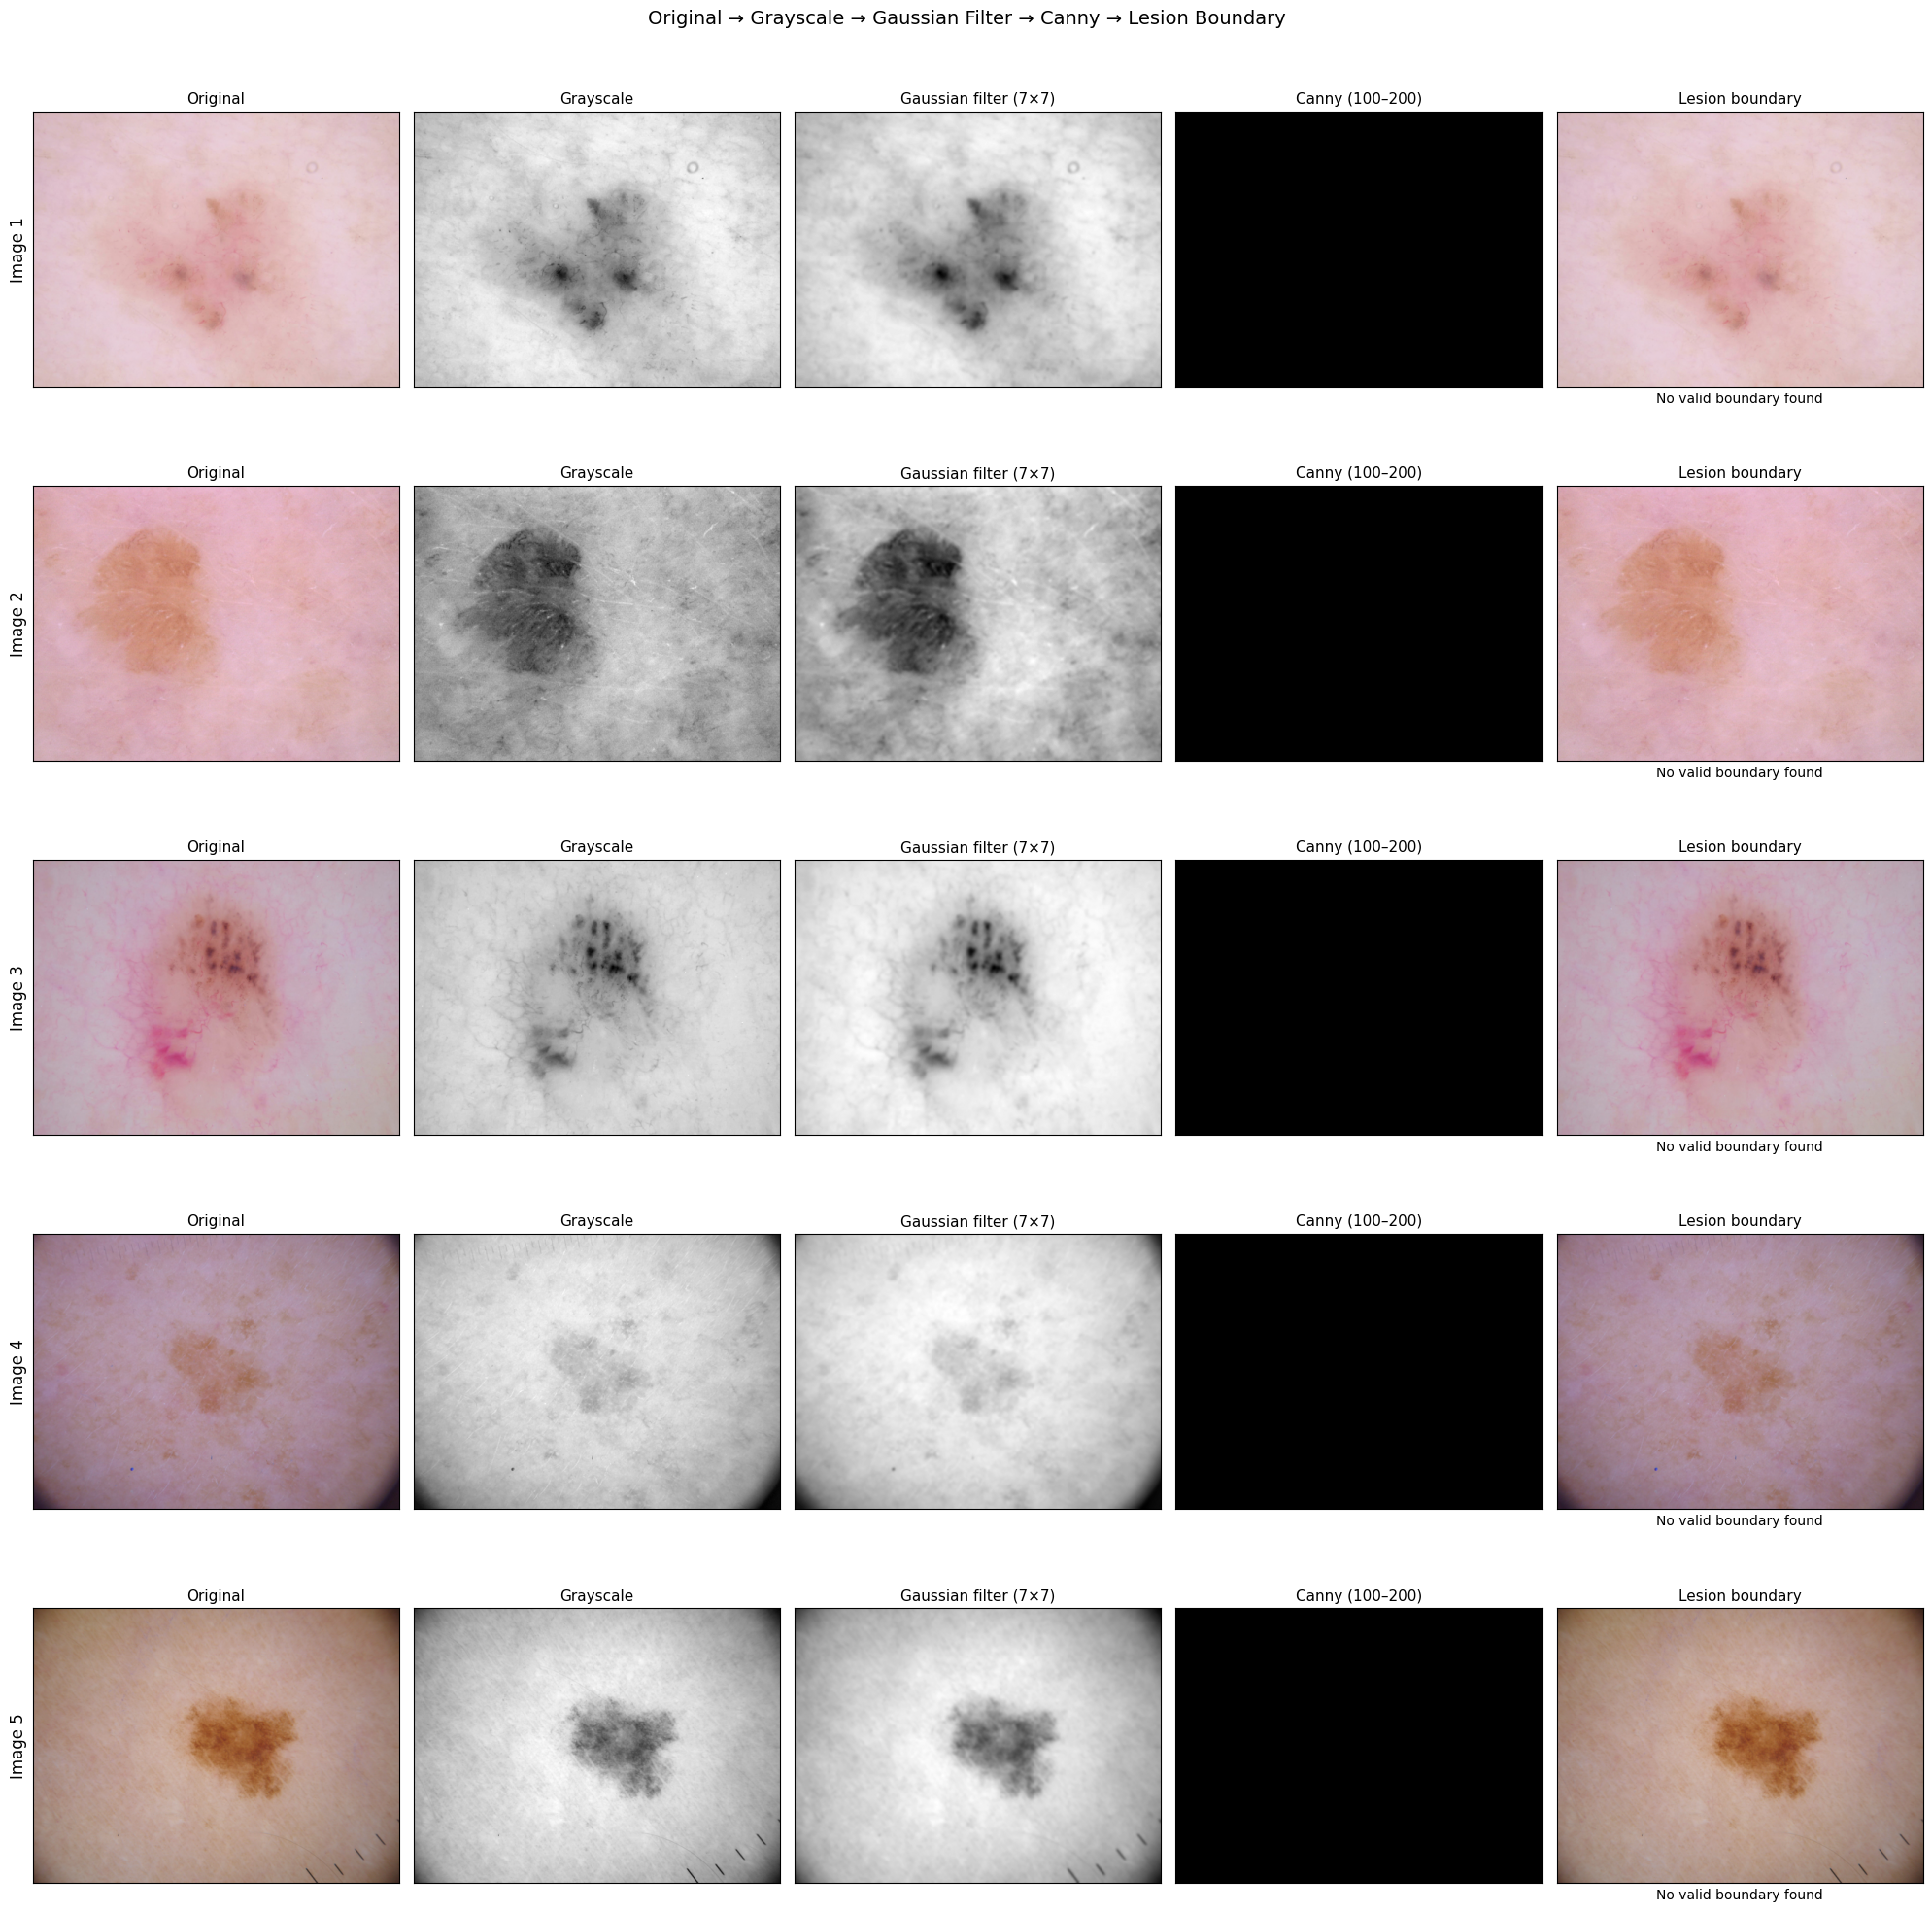


RESULTS TABLE (Area/Perimeter = from the Best Filter; the Gaussian+Canny columns match the visualization above)


,Image,Best Filter,Edge Method,Area (pixels),Perimeter (pixels),"Area, Gaussian+Canny (pixels)","Perimeter, Gaussian+Canny (pixels)",Area (% of image)
0,Image 1,Gaussian,Canny (100–200),0,0.0,0,0.0,0.0
1,Image 2,Gaussian,Canny (100–200),0,0.0,0,0.0,0.0
2,Image 3,Gaussian,Canny (100–200),0,0.0,0,0.0,0.0
3,Image 4,Gaussian,Canny (100–200),0,0.0,0,0.0,0.0
4,Image 5,Gaussian,Canny (100–200),0,0.0,0,0.0,0.0


In [5]:
# ============ CELL 5: TASKS 2-6 — PREPROCESS, CANNY x3, BEST THRESHOLD, BOUNDARY, AREA, PERIMETER ============
RESULT_ROWS, THR_ROWS, BESTREC = [], [], {}
for im in IMAGES:
    recs, bi = best_threshold(im, "Gaussian")
    BESTREC[im["name"]] = (recs, bi)
    for i, r in enumerate(recs):
        THR_ROWS.append(dict(Image=im["name"], Threshold=f"{r['thr'][0]}–{r['thr'][1]}", Density=r["stats"]["density"], Segments=r["stats"]["segments"],
                             Found=r["seg"]["found"], Separation=r["seg"]["sep"], Score=r["seg"]["score"], Selected=(i == bi)))
thr_df = pd.DataFrame(THR_ROWS)

# --- Task 3/4 figure: three Canny maps per image, best one starred ---
fig, axes = plt.subplots(len(IMAGES), 4, figsize=(16, 4 * len(IMAGES)))
for r_, im in enumerate(IMAGES):
    recs, bi = BESTREC[im["name"]]
    axes[r_, 0].imshow(recs[0]["gf"], cmap="gray"); axes[r_, 0].set_title(f"{im['name']}: Gaussian filtered", fontsize=10)
    for c_, r in enumerate(recs, start=1):
        axes[r_, c_].imshow(r["edge"], cmap="gray")
        axes[r_, c_].set_title(f"Canny {r['thr'][0]}–{r['thr'][1]}" + ("  ★ best" if c_ - 1 == bi else "") +
                               f"\n{r['stats']['density']:.1f}% edge px, {r['stats']['segments']} segments", fontsize=10,
                               color="green" if c_ - 1 == bi else "black")
for a in axes.ravel(): a.axis("off")
plt.suptitle("Tasks 3–4: three Canny threshold settings", y=1.0); plt.tight_layout(); save_fig("task3_canny_thresholds.png"); plt.show()

print("=== TASK 4: threshold selection (score = Lab colour separation of the region vs surrounding skin; halved if it touches the border) ===")
for im in IMAGES:
    recs, bi = BESTREC[im["name"]]
    b = recs[bi]; lo, hi = b["thr"]
    others = "; ".join(f"{r['thr'][0]}–{r['thr'][1]}: {r['stats']['density']:.1f}% edge px, " +
                       (f"boundary found (sep {r['seg']['sep']:.2f})" if r["seg"]["found"] else "no valid boundary") for r in recs)
    print(f"{im['name']}: selected {lo}–{hi}  | {others}")

# --- Task 5/6 + required visualization: Original -> Grayscale -> Gaussian -> Canny -> Lesion Boundary ---
fig, axes = plt.subplots(len(IMAGES), 5, figsize=(20, 4 * len(IMAGES)))
for r_, im in enumerate(IMAGES):
    recs, bi = BESTREC[im["name"]]; b = recs[bi]; seg = b["seg"]
    axes[r_, 0].imshow(im["rgb"]); axes[r_, 1].imshow(im["gray"], cmap="gray"); axes[r_, 2].imshow(b["gf"], cmap="gray")
    axes[r_, 3].imshow(b["edge"], cmap="gray"); axes[r_, 4].imshow(draw_boundary(im["rgb"], seg))
    for c_, t in enumerate(["Original", "Grayscale", f"Gaussian filter ({FILTER_K}×{FILTER_K})", f"Canny ({b['thr'][0]}–{b['thr'][1]})", "Lesion boundary"]):
        axes[r_, c_].set_title(t, fontsize=11)
    axes[r_, 0].set_ylabel(im["name"], fontsize=12)
    axes[r_, 4].set_xlabel(f"Area = {seg['area']} px   Perimeter = {seg['perimeter']:.1f} px" if seg["found"] else "No valid boundary found", fontsize=10)
    for a in axes[r_]: a.set_xticks([]); a.set_yticks([])
plt.suptitle("Original → Grayscale → Gaussian Filter → Canny → Lesion Boundary", y=1.0, fontsize=14)
plt.tight_layout(); save_fig("main_pipeline.png"); plt.show()

# --- Results table: best filter (Average / Gaussian / Median) at each image's selected threshold ---
for im in IMAGES:
    recs, bi = BESTREC[im["name"]]; thr = recs[bi]["thr"]
    cand = {f: run(im, f, "Canny", thr) for f in ["Average", "Gaussian", "Median"]}
    best_f = max(["Gaussian", "Average", "Median"], key=lambda f: cand[f][2]["score"])   # ties -> Gaussian
    seg_b, seg_g = cand[best_f][2], recs[bi]["seg"]
    RESULT_ROWS.append({"Image": im["name"], "Best Filter": best_f, "Edge Method": f"Canny ({thr[0]}–{thr[1]})",
                        "Area (pixels)": seg_b["area"], "Perimeter (pixels)": round(seg_b["perimeter"], 1),
                        "Area, Gaussian+Canny (pixels)": seg_g["area"], "Perimeter, Gaussian+Canny (pixels)": round(seg_g["perimeter"], 1),
                        "Area (% of image)": round(seg_g["area"] / im["gray"].size * 100, 1) if seg_g["found"] else 0.0})
results_df = pd.DataFrame(RESULT_ROWS)
print("\nRESULTS TABLE (Area/Perimeter = from the Best Filter; the Gaussian+Canny columns match the visualization above)")
display(results_df)
results_df.to_csv(os.path.join(OUT_DIR, "results_table.csv"), index=False)
thr_df.to_csv(os.path.join(OUT_DIR, "threshold_analysis.csv"), index=False)

FINAL COMPARISON (mean over the 5 images; labels are ranks among the 8 methods: top 2 Excellent, next 2 Good, next 2 Fair, last 2 Poor)


,Method,Noise Handling,Edge Quality,Boundary Detection,Overall Performance
0,Original + Sobel,Poor (34% of edge px are speckle),"Good (51% of boundary on real edges, 52% of edge px in long segments)","Good (3/5 found, separation 0.79)",Good (score 0.58)
1,Original + Canny,Poor (47% of edge px are speckle),"Fair (0% of boundary on real edges, 0% of edge px in long segments)","Fair (0/5 found, separation 0.00)",Poor (score 0.13)
2,Average + Sobel,Good (12% of edge px are speckle),"Excellent (76% of boundary on real edges, 77% of edge px in long segments)","Excellent (4/5 found, separation 1.43)",Excellent (score 0.86)
3,Average + Canny,Excellent (0% of edge px are speckle),"Fair (0% of boundary on real edges, 0% of edge px in long segments)","Fair (0/5 found, separation 0.00)",Fair (score 0.25)
4,Gaussian + Sobel,Fair (15% of edge px are speckle),"Excellent (73% of boundary on real edges, 70% of edge px in long segments)","Good (4/5 found, separation 1.12)",Good (score 0.79)
5,Gaussian + Canny,Excellent (0% of edge px are speckle),"Fair (0% of boundary on real edges, 0% of edge px in long segments)","Fair (0/5 found, separation 0.00)",Fair (score 0.25)
6,Median + Sobel,Fair (17% of edge px are speckle),"Good (73% of boundary on real edges, 69% of edge px in long segments)","Excellent (4/5 found, separation 1.24)",Excellent (score 0.80)
7,Median + Canny,Excellent (0% of edge px are speckle),"Fair (0% of boundary on real edges, 0% of edge px in long segments)","Fair (0/5 found, separation 0.00)",Fair (score 0.25)


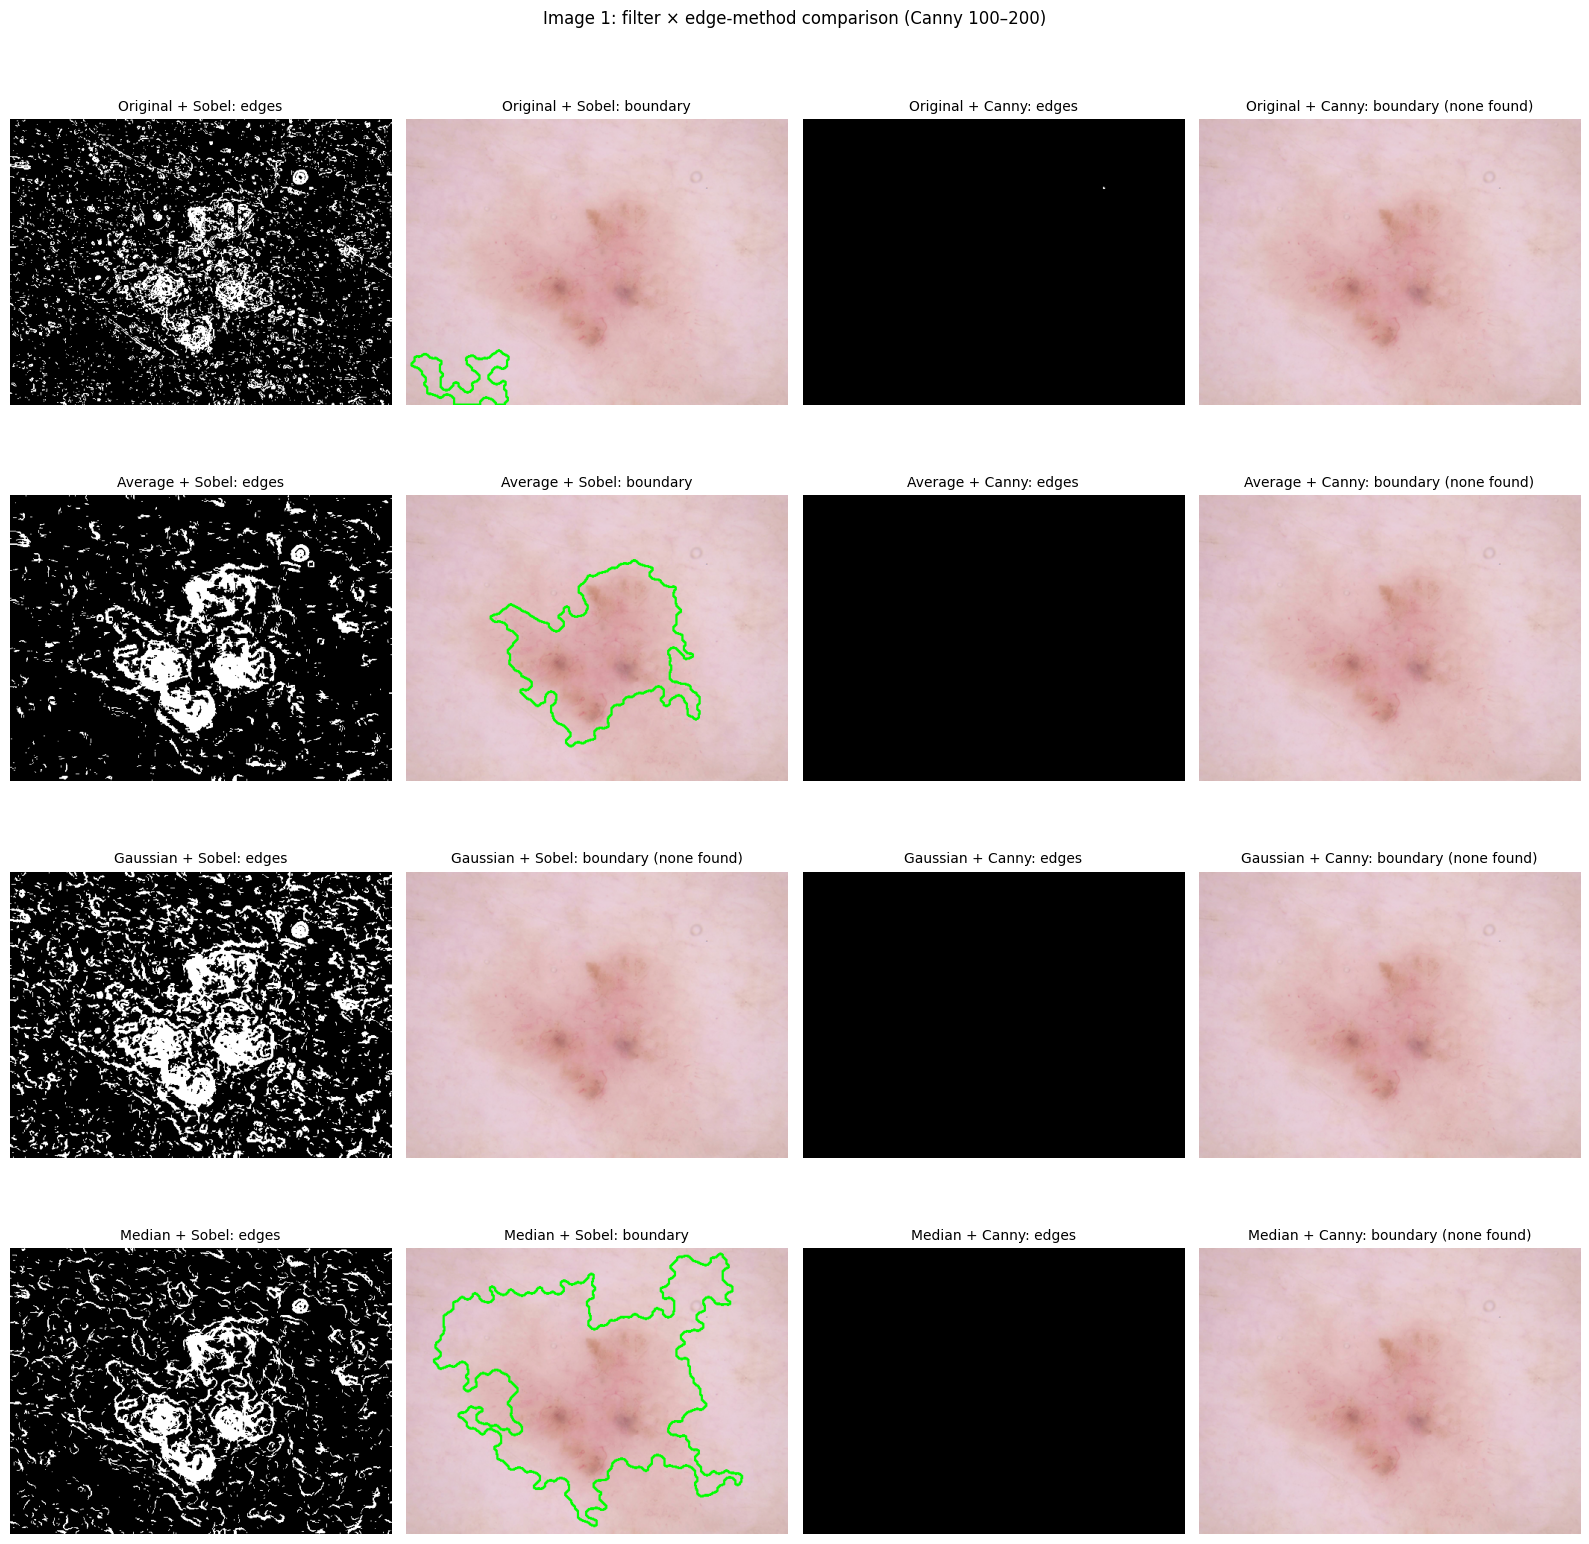

In [6]:
# ============ CELL 6: FINAL COMPARISON — {Original, Average, Gaussian, Median} x {Sobel, Canny} ============
FILTERS, METHODS = ["Original", "Average", "Gaussian", "Median"], ["Sobel", "Canny"]
rows = []
for im in IMAGES:
    recs, bi = BESTREC[im["name"]]; thr = recs[bi]["thr"]
    for f in FILTERS:
        for m in METHODS:
            gf, edge, seg, st = run(im, f, m, thr)
            rows.append(dict(Image=im["name"], Filter=f, Method=m, found=seg["found"], sep=seg["sep"], score=seg["score"], border=seg["border"], **st))
cmp_raw = pd.DataFrame(rows)
agg = cmp_raw.groupby(["Filter", "Method"], sort=False).agg(speckle=("speckle", "mean"), coverage=("coverage", "mean"), continuity=("continuity", "mean"), success=("found", "mean"),
                                                             sep=("sep", "mean"), density=("density", "mean"), segments=("segments", "mean")).reset_index()
agg["Name"] = agg["Filter"] + " + " + agg["Method"]
agg["edgeq"] = (agg["coverage"] + agg["continuity"]) / 2
agg["overall"] = ((1 - agg["speckle"]) + agg["edgeq"] + agg["success"] + agg["sep"] / max(agg["sep"].max(), 1e-9)) / 4

def rank_label(series, higher_better=True):
    r = series.rank(ascending=not higher_better, method="min")          # 1 = best
    return r.map(lambda x: "Excellent" if x <= 2 else "Good" if x <= 4 else "Fair" if x <= 6 else "Poor")

agg["nh"], agg["eq"] = rank_label(agg["speckle"], False), rank_label(agg["edgeq"], True)
agg["bd"], agg["ov"] = rank_label(agg["success"] + agg["sep"] / max(agg["sep"].max(), 1e-9), True), rank_label(agg["overall"], True)
final_df = pd.DataFrame({
    "Method": agg["Name"],
    "Noise Handling": agg.apply(lambda r: f"{r['nh']} ({r['speckle']*100:.0f}% of edge px are speckle)", axis=1),
    "Edge Quality": agg.apply(lambda r: f"{r['eq']} ({r['coverage']*100:.0f}% of boundary on real edges, {r['continuity']*100:.0f}% of edge px in long segments)", axis=1),
    "Boundary Detection": agg.apply(lambda r: f"{r['bd']} ({int(round(r['success']*len(IMAGES)))}/{len(IMAGES)} found, separation {r['sep']:.2f})", axis=1),
    "Overall Performance": agg.apply(lambda r: f"{r['ov']} (score {r['overall']:.2f})", axis=1)})
print("FINAL COMPARISON (mean over the %d images; labels are ranks among the 8 methods: top 2 Excellent, next 2 Good, next 2 Fair, last 2 Poor)" % len(IMAGES))
display(final_df)
final_df.to_csv(os.path.join(OUT_DIR, "final_comparison.csv"), index=False)
agg.drop(columns=["nh", "eq", "bd", "ov"]).to_csv(os.path.join(OUT_DIR, "final_comparison_numeric.csv"), index=False)

# Visual: Image 1 across all 8 methods
im = IMAGES[0]; thr = BESTREC[im["name"]][0][BESTREC[im["name"]][1]]["thr"]
fig, axes = plt.subplots(len(FILTERS), 4, figsize=(16, 4 * len(FILTERS)))
for r_, f in enumerate(FILTERS):
    for c_, m in enumerate(METHODS):
        gf, edge, seg, st = run(im, f, m, thr)
        axes[r_, 2 * c_].imshow(edge, cmap="gray"); axes[r_, 2 * c_].set_title(f"{f} + {m}: edges", fontsize=10)
        axes[r_, 2 * c_ + 1].imshow(draw_boundary(im["rgb"], seg)); axes[r_, 2 * c_ + 1].set_title(f"{f} + {m}: boundary" + ("" if seg["found"] else " (none found)"), fontsize=10)
for a in axes.ravel(): a.axis("off")
plt.suptitle(f"{im['name']}: filter × edge-method comparison (Canny {thr[0]}–{thr[1]})", y=1.0); plt.tight_layout(); save_fig("method_comparison_image1.png"); plt.show()

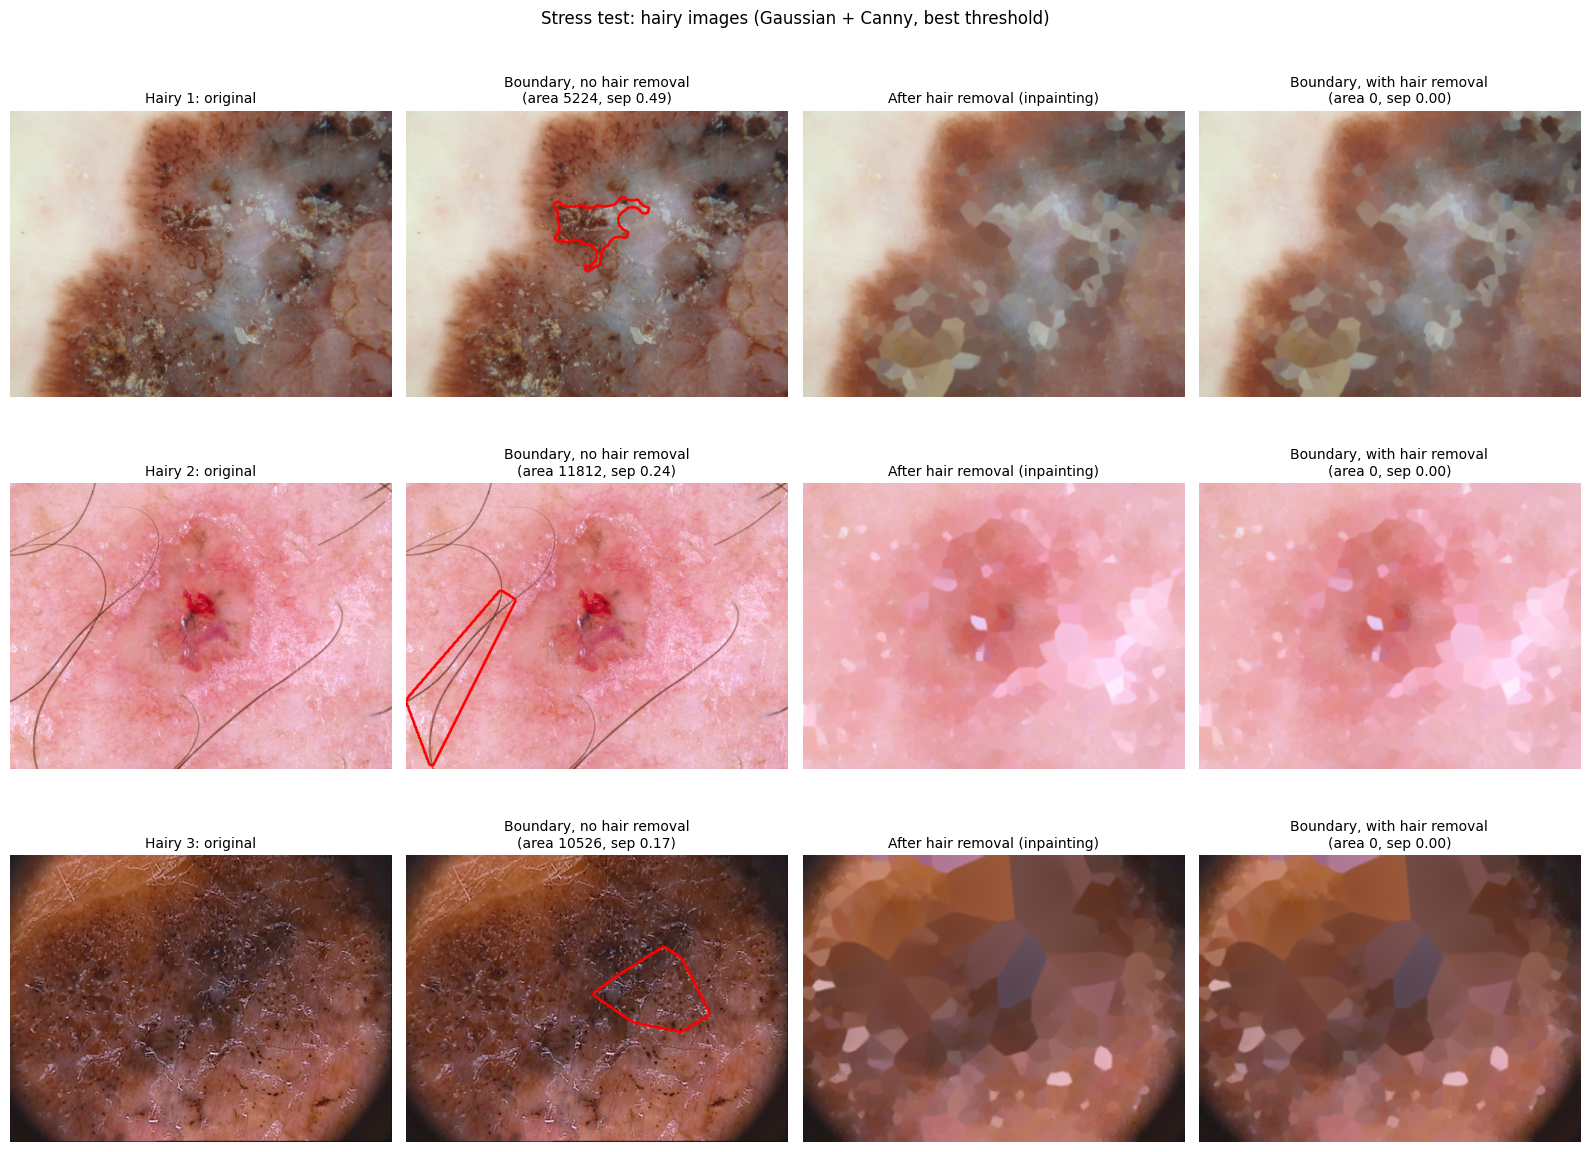

,Image,hair_score,found_before,area_before,sep_before,found_after,area_after,sep_after
0,Hairy 1 (melanoma),0.332,True,5224,0.49,False,0,0.0
1,Hairy 2 (basal cell carcinoma),0.434,True,11812,0.24,False,0,0.0
2,Hairy 3 (melanoma),0.661,True,10526,0.17,False,0,0.0


In [7]:
# ============ CELL 7: STRESS TEST — HAIRY IMAGES, WITH / WITHOUT HAIR REMOVAL (for Questions 5 and 6) ============
def remove_hair(rgb):
    bh = cv2.morphologyEx(to_gray(rgb), cv2.MORPH_BLACKHAT, cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17)))
    _, m = cv2.threshold(bh, 10, 255, cv2.THRESH_BINARY)
    return cv2.inpaint(rgb, cv2.dilate(m, np.ones((3, 3), np.uint8)), 3, cv2.INPAINT_TELEA)

def make_im(rgb):
    return dict(rgb=rgb, gray=to_gray(rgb), lab=cv2.cvtColor(cv2.GaussianBlur(rgb, (5, 5), 0), cv2.COLOR_RGB2LAB))

STRESS = []
if hairy:
    fig, axes = plt.subplots(len(hairy), 4, figsize=(16, 4 * len(hairy)))
    axes = np.atleast_2d(axes)
    for r_, (hs, p, c) in enumerate(hairy):
        a, b = make_im(load_rgb(p)), make_im(remove_hair(load_rgb(p)))
        out = {}
        for tag, im_ in (("no hair removal", a), ("with hair removal", b)):
            recs, bi = best_threshold(im_, "Gaussian"); out[tag] = (recs[bi]["seg"], recs[bi]["thr"], recs[bi]["stats"])
        STRESS.append(dict(Image=f"Hairy {r_+1} ({c})", hair_score=round(hs, 3),
                           found_before=out["no hair removal"][0]["found"], area_before=out["no hair removal"][0]["area"], sep_before=round(out["no hair removal"][0]["sep"], 2),
                           found_after=out["with hair removal"][0]["found"], area_after=out["with hair removal"][0]["area"], sep_after=round(out["with hair removal"][0]["sep"], 2)))
        axes[r_, 0].imshow(a["rgb"]); axes[r_, 0].set_title(f"Hairy {r_+1}: original", fontsize=10)
        axes[r_, 1].imshow(draw_boundary(a["rgb"], out["no hair removal"][0], (255, 0, 0)))
        axes[r_, 1].set_title(f"Boundary, no hair removal\n(area {out['no hair removal'][0]['area']}, sep {out['no hair removal'][0]['sep']:.2f})", fontsize=10)
        axes[r_, 2].imshow(b["rgb"]); axes[r_, 2].set_title("After hair removal (inpainting)", fontsize=10)
        axes[r_, 3].imshow(draw_boundary(b["rgb"], out["with hair removal"][0]))
        axes[r_, 3].set_title(f"Boundary, with hair removal\n(area {out['with hair removal'][0]['area']}, sep {out['with hair removal'][0]['sep']:.2f})", fontsize=10)
    for a_ in axes.ravel(): a_.axis("off")
    plt.suptitle("Stress test: hairy images (Gaussian + Canny, best threshold)", y=1.0); plt.tight_layout(); save_fig("stress_test_hair.png"); plt.show()
    stress_df = pd.DataFrame(STRESS); display(stress_df); stress_df.to_csv(os.path.join(OUT_DIR, "stress_test_hair.csv"), index=False)
else:
    print("Custom IMAGE_PATHS used: stress test skipped.")

In [8]:
# ============ CELL 8: REPORT (tables + answers with your numbers), SAVE EVERYTHING ============
def df_to_md(df):
    cols = list(df.columns)
    lines = ["| " + " | ".join(map(str, cols)) + " |", "|" + "|".join("---" for _ in cols) + "|"]
    for _, r in df.iterrows(): lines.append("| " + " | ".join(str(r[c]) for c in cols) + " |")
    return "\n".join(lines)

n = len(IMAGES)
ts = thr_df.groupby("Threshold", sort=False).agg(density=("Density", "mean"), segments=("Segments", "mean"), found=("Found", "sum"),
                                                 sep=("Separation", "mean"), selected=("Selected", "sum")).reset_index()
thr_table = pd.DataFrame({"Canny threshold": ts["Threshold"], "Mean edge pixels (%)": ts["density"].round(2), "Mean edge segments": ts["segments"].round(0).astype(int),
                          "Valid boundary found": ts["found"].astype(int).astype(str) + f"/{n}", "Mean separation": ts["sep"].round(2), "Times selected as best": ts["selected"].astype(int)})
best_thr = ts.loc[ts["selected"].idxmax(), "Threshold"]
lo_t, mid_t, hi_t = ts["Threshold"].tolist()

issues = []
for im in IMAGES:
    recs, bi = BESTREC[im["name"]]; s = recs[bi]["seg"]
    if not s["found"]: issues.append(f"{im['name']}: no valid lesion region was found.")
    else:
        if s["border"]: issues.append(f"{im['name']}: boundary touches the image border (lesion cut off by the frame or a dark vignette).")
        if s["sep"] < 1.0: issues.append(f"{im['name']}: low colour contrast with the surrounding skin (separation {s['sep']:.2f}), so the boundary is uncertain.")
        if s["kind"] == "hull": issues.append(f"{im['name']}: the edge ring had gaps, so a convex hull had to close the boundary.")
if not issues: issues.append("No automatic warning flags were raised on the selected images (still inspect the figures).")

stress_txt = ""
if STRESS:
    stress_txt = "\n\nStress test on hairy images (`figures/stress_test_hair.png`):\n\n" + df_to_md(pd.DataFrame(STRESS).rename(columns={
        "hair_score": "Hair score", "found_before": "Found (before)", "area_before": "Area before", "sep_before": "Separation before",
        "found_after": "Found (after)", "area_after": "Area after", "sep_after": "Separation after"}))

gc = agg.set_index("Name")
def g(name, col): return gc.loc[name, col]
report = f"""# Lab 04 — Skin Lesion Boundary Detection Using Canny Edge Detection

Dataset: ISIC skin lesions (Kaggle). Images resized to a longest side of {MAX_SIDE} px, so **areas and perimeters are in these pixels** (not millimetres).
Image selection: from {POOL} random images, the {n} with the least hair/ruler marks were used (hair score = share of thin dark structures).
Filters: Average / Gaussian / Median, all {FILTER_K}×{FILTER_K}. Canny thresholds tested: {", ".join(f"{a}–{b}" for a, b in CANNY_THRESHOLDS)}.

## Method

1. Load image → grayscale → filter ({FILTER_K}×{FILTER_K}).
2. Canny edge detection with three threshold pairs.
3. Boundary extraction from the edge map: morphological closing (ellipse {CLOSE_K}×{CLOSE_K}, and a larger one as backup) joins broken edges; enclosed regions are filled; small tails are removed by opening; candidate regions between {MIN_FRAC*100:.0f}% and {MAX_FRAC*100:.0f}% of the image are kept; the contour of the best candidate is the lesion boundary.
4. **Area** = number of pixels inside the boundary (mask pixel count). **Perimeter** = contour length (`cv2.arcLength`).
5. **How the best threshold/filter is chosen:** there are no ground-truth masks in this dataset, so each candidate boundary gets a score = colour separation (Lab distance between the region and a 15 px ring of skin around it, divided by their spread), halved if the region touches the image border. This score does not use the edge map, so it is an independent but **indirect** measure of boundary quality, not an accuracy measure.

## Required visualization

Original → Grayscale → Gaussian Filter → Canny → Lesion Boundary:

![Pipeline](figures/main_pipeline.png)

Three Canny thresholds (best marked ★):

![Thresholds](figures/task3_canny_thresholds.png)

## Results table

Area and Perimeter come from the Best Filter. The last columns repeat the numbers for the Gaussian + Canny pipeline shown in the figure.

{df_to_md(results_df)}

## Threshold analysis (Gaussian + Canny)

{df_to_md(thr_table)}

## Final comparison

Mean over the {n} images, Canny at each image's selected threshold. Labels are ranks among the 8 methods (top 2 Excellent, next 2 Good, next 2 Fair, last 2 Poor); the numbers in brackets are the measurements behind them:
speckle = share of edge pixels in fragments under {SPECKLE_PX} px (lower is better); boundary on real edges = share of the final boundary lying within 3 px of a detected edge; long segments = share of edge pixels in unbroken segments of at least 100 px (continuity); Edge Quality ranks the average of those last two; separation = region-vs-skin colour separation.

{df_to_md(final_df)}

![Method comparison](figures/method_comparison_image1.png)
{stress_txt}

## Questions

**1. Why is Gaussian filtering applied before Canny detection?**
Edge detection is based on image gradients, and gradients amplify noise, skin texture and tiny hairs, which would show up as many false edges. A Gaussian filter removes high-frequency detail first, so only strong, larger-scale transitions (such as the lesion border) survive. OpenCV's `cv2.Canny` does not smooth the image itself, so this step has to be done explicitly. In this experiment, Original + Canny had {g('Original + Canny','speckle')*100:.0f}% of its edge pixels in tiny speckle fragments, versus {g('Gaussian + Canny','speckle')*100:.0f}% for Gaussian + Canny. The trade-off is that too much blur shifts and weakens the real border.

**2. How did the three Canny threshold settings affect the result?**
Mean edge pixels per image: {lo_t}: {ts.loc[0,'density']:.2f}%, {mid_t}: {ts.loc[1,'density']:.2f}%, {hi_t}: {ts.loc[2,'density']:.2f}%. Valid boundaries were found in {int(ts.loc[0,'found'])}/{n}, {int(ts.loc[1,'found'])}/{n} and {int(ts.loc[2,'found'])}/{n} images respectively. Lower thresholds keep weak edges (more detail, but also skin texture, hair and internal lesion structure); higher thresholds keep only the strongest edges, so the border becomes fragmented or disappears when its contrast is low.

**3. Which threshold produced the best lesion boundary?**
{best_thr} was selected most often ({int(ts['selected'].max())} of {n} images). The selection is per image (see the Task 4 printout above), and it rests on the colour-separation score, so inspect the figure to confirm that you agree with it visually.

**4. Why are edges useful for detecting skin lesions?**
A lesion is defined by a change in colour/intensity between it and the surrounding skin, and that change is exactly what an edge detector finds. The border is clinically important (border irregularity, asymmetry and diameter are part of the ABCD rule), and area and perimeter can be measured directly from it. Edges also depend on local contrast rather than absolute brightness, so they are less affected by overall lighting differences than a single fixed intensity threshold.

**5. What problems did you observe in detecting the lesion boundary?**
Automatic flags on the selected images:
""" + "\n".join(f"- {t}" for t in issues) + f"""

Other limitations of this method: hair and ruler marks create strong edges that can attach to or replace the lesion border (see the stress test); lesions with a soft, gradual border give weak edges that thresholds break up; internal lesion texture produces extra edges; and Canny gives open edge fragments, so closing/filling is needed and its kernel size is a compromise between joining gaps and merging nearby structures. There are no ground-truth masks here, so I could not measure accuracy (for example Dice/IoU); the scores are indirect.

**6. How could your method be improved?**
- Remove hair before edge detection (black-hat + inpainting, as in the stress test).
- Detect edges on a better channel than plain grayscale (a Lab channel or PCA of the colour channels with the most lesion/skin contrast).
- Choose the Canny thresholds automatically from each image's gradient statistics instead of using fixed pairs.
- Replace closing + hole-filling with a seeded method (GrabCut, watershed, or active contours) initialised from the Canny region, and smooth the final contour (ellipse or polygon fit).
- Crop dark vignettes/rulers and handle lesions touching the border.
- Validate against ISIC ground-truth masks (Dice/IoU) and, for best accuracy, use a trained segmentation network such as U-Net.
"""
open(os.path.join(OUT_DIR, "Lab04_Report.md"), "w").write(report)
print(report[:3500], "\n...\n[report continues in Lab04_Report.md]")

shutil.make_archive("/content/lab04_outputs", "zip", OUT_DIR)
print("\nSaved to", OUT_DIR, "and /content/lab04_outputs.zip")
try:
    from google.colab import files; files.download("/content/lab04_outputs.zip")
except Exception: pass

# Lab 04 — Skin Lesion Boundary Detection Using Canny Edge Detection

Dataset: ISIC skin lesions (Kaggle). Images resized to a longest side of 512 px, so **areas and perimeters are in these pixels** (not millimetres).
Image selection: from 80 random images, the 5 with the least hair/ruler marks were used (hair score = share of thin dark structures).
Filters: Average / Gaussian / Median, all 7×7. Canny thresholds tested: 50–100, 100–200, 150–250.

## Method

1. Load image → grayscale → filter (7×7).
2. Canny edge detection with three threshold pairs.
3. Boundary extraction from the edge map: morphological closing (ellipse 13×13, and a larger one as backup) joins broken edges; enclosed regions are filled; small tails are removed by opening; candidate regions between 2% and 70% of the image are kept; the contour of the best candidate is the lesion boundary.
4. **Area** = number of pixels inside the boundary (mask pixel count). **Perimeter** = contour length (`cv2.arcLength`).
5. **How the

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>